# JEPA evaluation — agentic spatial SIR

This notebook explores the three-channel agentic SIR dataset and evaluates a trained decoder-free JEPA model.

The questions are:

1. **Does the dataset contain a learnable vaccination signal?** Higher vaccination should suppress infection while preserving a pool of susceptibles when possible.
2. **Did JEPA learn useful dynamics?** Multi-step latent rollouts must beat persistence.
3. **Does the latent retain epidemic state?** `infected_count` and `susceptible_count` must be linearly readable.
4. **Does the model understand dose response?** It must predict lower infection and reduced susceptibles as vaccination intensity rises.
5. **Can multi-objective MPC trade infection suppression against over-vaccination?**

The ABM is a spatial benchmark with mobile agents and local transmission, not a calibrated epidemiological model.


In [1]:
%matplotlib inline
from pathlib import Path
import json
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Make this work whether Jupyter starts in the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from koopman_control.paths import output_root

OUTPUT_ROOT = output_root()
RUN_DIR = Path(OUTPUT_ROOT / "jepa_training/jepa-sir-v2-h10-linear")
if not RUN_DIR.is_absolute():
    RUN_DIR = PROJECT_ROOT / RUN_DIR

run_config_path = RUN_DIR / "config.json"
if run_config_path.exists():
    RUN_CONFIG = json.loads(run_config_path.read_text())
    DATASET = Path(RUN_CONFIG["dataset"])
    if not DATASET.is_absolute():
        DATASET = PROJECT_ROOT / DATASET
else:
    RUN_CONFIG = {}
    DATASET = PROJECT_ROOT / "data/agentic_sir_images_v2/dataset.h5"

MANIFEST = DATASET.parent / "manifest.json"
CHECKPOINTS = sorted((RUN_DIR / "checkpoints").glob("best-*.ckpt"))
CKPT = max(CHECKPOINTS, key=lambda p: p.stat().st_mtime) if CHECKPOINTS else None
METRICS = RUN_DIR / "logs/metrics.csv"
MODEL_READY = CKPT is not None and METRICS.exists()
print(f"dataset:     {DATASET}")
print(f"run:         {RUN_DIR}")
print(f"checkpoint:  {CKPT}")
print(f"model ready: {MODEL_READY}")
if not MODEL_READY:
    print("Dataset exploration works now; model-evaluation cells require a completed training run.")


dataset:     /Users/jacobevarts/BagheriLab/abm-control/data/agentic_sir_images_v2/dataset.h5
run:         /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-sir-v2-h10-linear
checkpoint:  /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-sir-v2-h10-linear/checkpoints/best-002-6768-0.047901.ckpt
model ready: True


## 1. Dataset inventory

Frames have shape `(time, 3, height, width)`: susceptible occupancy, infected occupancy, and recovered occupancy. The HDF5 file stores all three as `uint8`; dividing by `frame_scale=255` recovers values in `[0, 1]`.

The observables are compact macrostates used only for evaluation and the post-hoc MPC readout—not as JEPA training targets.


In [2]:
manifest = json.loads(MANIFEST.read_text()) if MANIFEST.exists() else {}
with h5py.File(DATASET, "r") as h5:
    run_ids = sorted(h5["runs"])
    obs_names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5.attrs["obs_names"]]
    frame_scale = float(h5.attrs.get("frame_scale", 1.0))
    splits = {s: sum(h5["runs"][r].attrs["split"] == s for r in run_ids) for s in ("train", "val", "test")}
    excitations = {}
    shapes = set()
    for r in run_ids:
        g = h5["runs"][r]
        exc = str(g.attrs["excitation"])
        excitations[exc] = excitations.get(exc, 0) + 1
        shapes.add(g["frames"].shape)

print(f"runs: {len(run_ids)}  split counts: {splits}")
print(f"frame shapes: {sorted(shapes)}  frame_scale: {frame_scale:g}")
print(f"observables ({len(obs_names)}): {obs_names}")
print("excitation counts:", dict(sorted(excitations.items())))
print("ABM config:", manifest.get("config", {}))


runs: 630  split counts: {'train': 378, 'val': 126, 'test': 126}
frame shapes: [(201, 3, 64, 64)]  frame_scale: 1
observables (12): ['susceptible_count', 'infected_count', 'recovered_count', 'susceptible_frac', 'infected_frac', 'recovered_frac', 'cumulative_incidence', 'infected_centroid_x', 'infected_centroid_y', 'infected_spread', 'population', 'grid_cells']
excitation counts: {'chirp': 90, 'constant': 90, 'prbs': 90, 'ramp': 90, 'rpwc': 90, 'staircase': 90, 'zero': 90}
ABM config: {'steps': 200, 'seeds': 5, 'seed_offset': 0, 'n_agents': [800, 1200], 'initial_infected': [20, 32, 48], 'seed_centers': [[0.3, 0.3], [0.5, 0.5], [0.7, 0.7]], 'seed_radius': 5.0, 'excitations': ['zero', 'constant', 'rpwc', 'prbs', 'ramp', 'staircase', 'chirp'], 'width': 64, 'height': 64, 'infection_prob': 0.45, 'recovery_prob': 0.05, 'move_prob': 0.85, 'vaccine_effectiveness': 0.028, 'vaccine_delay_fraction': 0.4}


## 2. Spatial channels through time

Unlike compartment ODEs, infection spreads locally on a grid: agents move, transmit in Moore neighborhoods, and vaccination converts susceptibles to recovered with a delivery lag. Choose any trajectory below to inspect how the spatial pattern evolves under the excitation signal.


/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_53469/1332617938.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


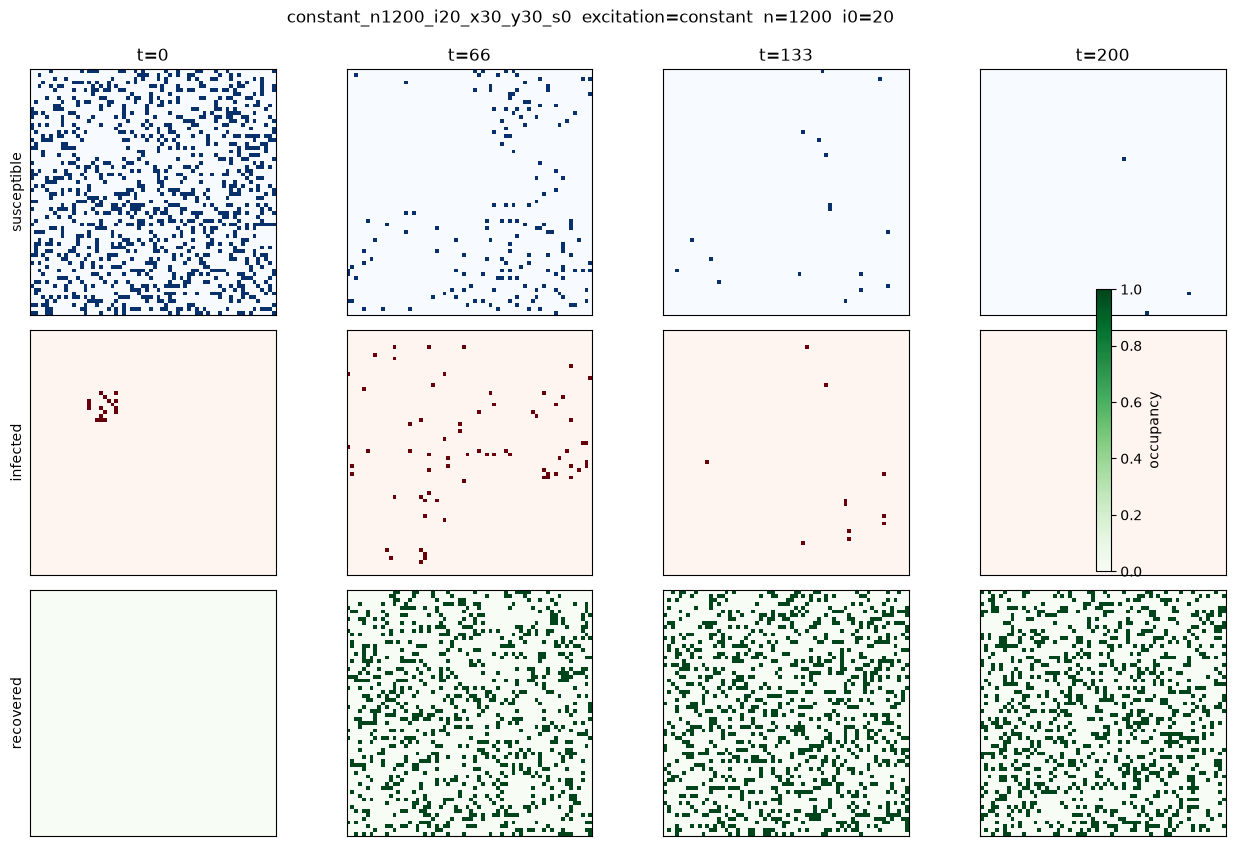

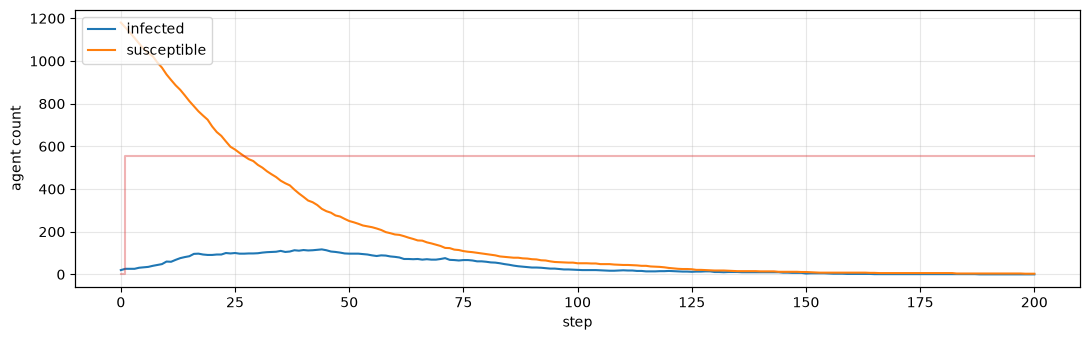

In [3]:
EXAMPLE_EXCITATION = "constant"
with h5py.File(DATASET, "r") as h5:
    candidates = [r for r in sorted(h5["runs"]) if str(h5["runs"][r].attrs["excitation"]) == EXAMPLE_EXCITATION]
    example_id = candidates[0] if candidates else sorted(h5["runs"])[0]
    g = h5["runs"][example_id]
    frames = np.asarray(g["frames"], dtype=np.float32) / float(h5.attrs.get("frame_scale", 1.0))
    controls = np.asarray(g["control"], dtype=float)
    example_meta = dict(g.attrs)
    names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5.attrs["obs_names"]]
    obs = np.asarray(g["obs"], dtype=float)

channel_names = ["susceptible", "infected", "recovered"]
cmaps = ["Blues", "Reds", "Greens"]
times = np.linspace(0, len(frames) - 1, 4, dtype=int)
fig, axes = plt.subplots(3, len(times), figsize=(13, 8.5), squeeze=False)
for row, (name, cmap) in enumerate(zip(channel_names, cmaps)):
    for col, t in enumerate(times):
        im = axes[row, col].imshow(frames[t, row], vmin=0, vmax=1, cmap=cmap)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(f"t={t}")
        if col == 0:
            axes[row, col].set_ylabel(name)
fig.colorbar(im, ax=axes, fraction=0.014, pad=0.02, label="occupancy")
fig.suptitle(
    f"{example_id}  excitation={example_meta.get('excitation', '?')}  "
    f"n={example_meta.get('n_agents', '?')}  i0={example_meta.get('initial_infected', '?')}",
    y=0.99,
)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 3.5))
ii, si = names.index("infected_count"), names.index("susceptible_count")
ax.plot(obs[:, ii], label="infected")
ax.plot(obs[:, si], label="susceptible")
ax2 = ax.twinx()
ax2.step(np.arange(len(controls)), controls, where="post", color="C3", alpha=0.35, label="vaccination u")
ax2.set_ylim(-0.05, 1.05); ax2.set_yticks([])
ax.set_xlabel("step"); ax.set_ylabel("agent count"); ax.grid(alpha=0.3)
ax.legend(loc="upper left"); fig.tight_layout(); plt.show()


## 3. Do the excitation regimes create useful system-identification data?

A useful dataset must contain both uncontrolled outbreaks and varied vaccination timing/intensity. The plots below compare one trajectory from each excitation family. Look for graded infection suppression—not immediate extinction under every nonzero dose—and a remaining susceptible pool when vaccination is moderate.


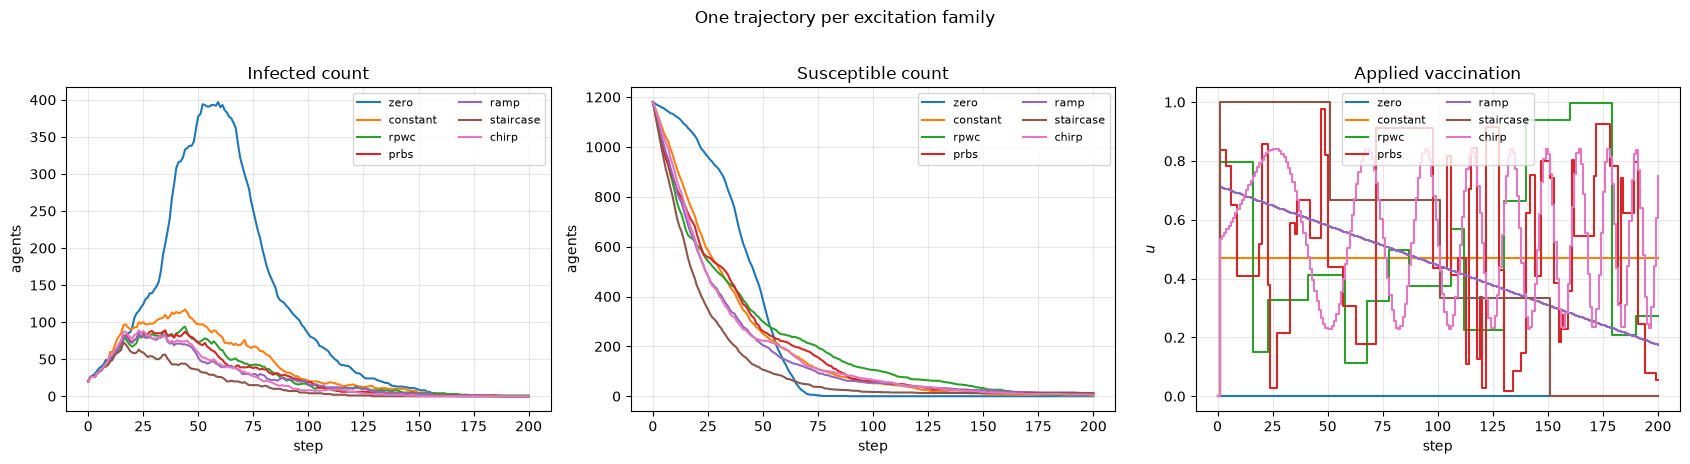

In [4]:
preferred = ["zero", "constant", "rpwc", "prbs", "ramp", "staircase", "chirp"]
trajectories = {}
with h5py.File(DATASET, "r") as h5:
    names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5.attrs["obs_names"]]
    ii, si = names.index("infected_count"), names.index("susceptible_count")
    for run_id in sorted(h5["runs"]):
        g = h5["runs"][run_id]
        exc = g.attrs["excitation"]
        exc = exc.decode() if isinstance(exc, bytes) else str(exc)
        if exc in preferred and exc not in trajectories:
            trajectories[exc] = {
                "obs": np.asarray(g["obs"], dtype=float),
                "u": np.asarray(g["control"], dtype=float),
            }

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for exc in preferred:
    if exc not in trajectories:
        continue
    tr = trajectories[exc]
    axes[0].plot(tr["obs"][:, ii], label=exc)
    axes[1].plot(tr["obs"][:, si], label=exc)
    axes[2].step(np.arange(len(tr["u"])), tr["u"], where="post", label=exc)
axes[0].set_title("Infected count"); axes[0].set_ylabel("agents")
axes[1].set_title("Susceptible count"); axes[1].set_ylabel("agents")
axes[2].set_title("Applied vaccination"); axes[2].set_ylabel("$u$")
for ax in axes:
    ax.set_xlabel("step"); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
fig.suptitle("One trajectory per excitation family", y=1.02)
fig.tight_layout(); plt.show()


## 4. Load the trained JEPA and compute shared diagnostics

Set `RUN_DIR` in the setup cell if your run name differs. This cell deliberately fails with a clear message when training has not produced a checkpoint yet.

The readout is fit only on training trajectories. Validation trajectories remain held out for all figures below. Infected centroids are excluded because they are unstable when the outbreak is small or spatially diffuse.


In [5]:
if not MODEL_READY:
    raise FileNotFoundError(
        f"No completed run at {RUN_DIR}. Update RUN_DIR or finish training before running this cell."
    )

from jepa_control import evaluate as ev
from jepa_control import plots as jp

N_PROBE_TRAIN = 40
SCORE_HORIZON = int(RUN_CONFIG.get("horizon", 10))
CONTROL_OBS = "infected_count"

model = ev.load_model(CKPT)
val = ev.load_split_trajectories(DATASET, "val")
test = ev.load_split_trajectories(DATASET, "test")
probe_train = ev.load_split_trajectories(DATASET, "train", N_PROBE_TRAIN)

enc = ev.encode_all(model, val)
enc_train = ev.encode_all(model, probe_train)
readout = ev.fit_readout(enc_train)
r2_val = ev.readout_r2(readout, enc)

fitted = ev.fit_latent_linear(model, enc)
herr = ev.horizon_errors(model, enc, fitted)
pca = ev.latent_pca(enc)
probe = ev.linear_probe(model, probe_train, val)
infected_skill = ev.readout_rollout_skill(model, enc, readout, obs_name="infected_count")
susceptible_skill = ev.readout_rollout_skill(model, enc, readout, obs_name="susceptible_count")

h = min(SCORE_HORIZON, len(herr["steps"]) - 1)
print(f"latent dim: {model.latent_dim}; training horizon: {model.hparams.horizon}")
print(f"val prediction skill @ h={h}: {herr['skill_full'][h]:+.3f}  (persistence {herr['skill_persistence'][h]:+.3f})")
print(f"val infected:   readout R²={r2_val['infected_count']:+.3f}, rollout corr={infected_skill['corr']:+.3f}, RMSE={infected_skill['rmse']:.2f}")
print(f"val susceptible: readout R²={r2_val['susceptible_count']:+.3f}, rollout corr={susceptible_skill['corr']:+.3f}, RMSE={susceptible_skill['rmse']:.2f}")


latent dim: 16; training horizon: 10
val prediction skill @ h=10: +0.666  (persistence +0.087)
val infected:   readout R²=+0.468, rollout corr=+0.468, RMSE=63.31
val susceptible: readout R²=+0.924, rollout corr=+0.933, RMSE=108.29


## 5. Training health and multi-step dynamics

The first figure checks optimization and collapse. The participation ratio should not steadily decay toward one.

The second figure is the most important dynamics test. Positive skill means the rollout beats predicting the mean latent; the JEPA curve should also beat **persistence**, which simply freezes the initial latent. Judge the model most strongly near its training horizon; much longer rollouts are extrapolation.


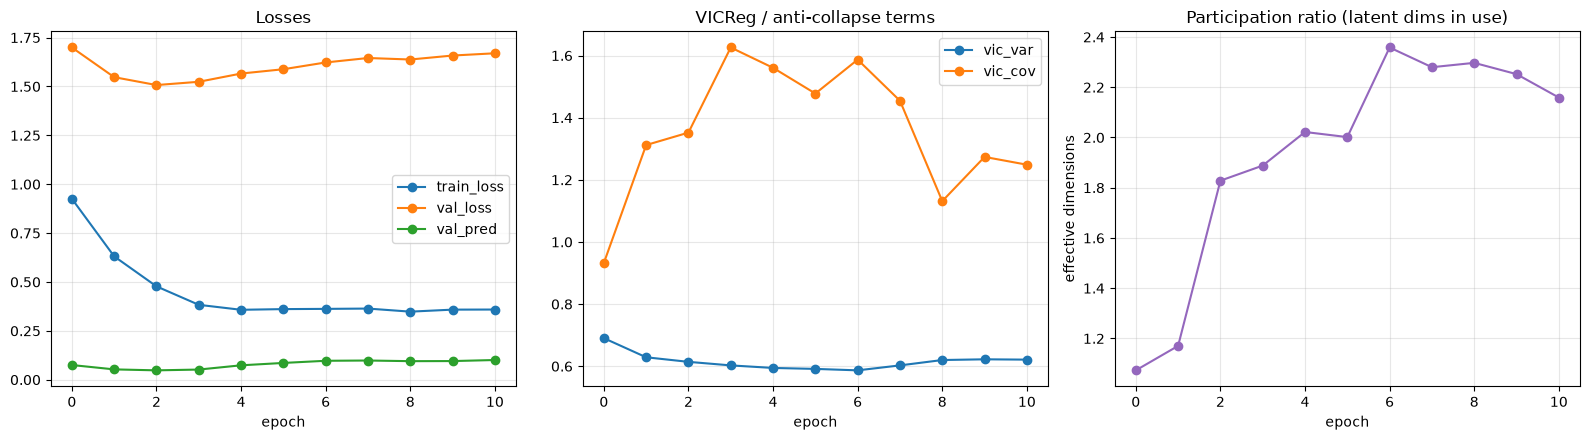

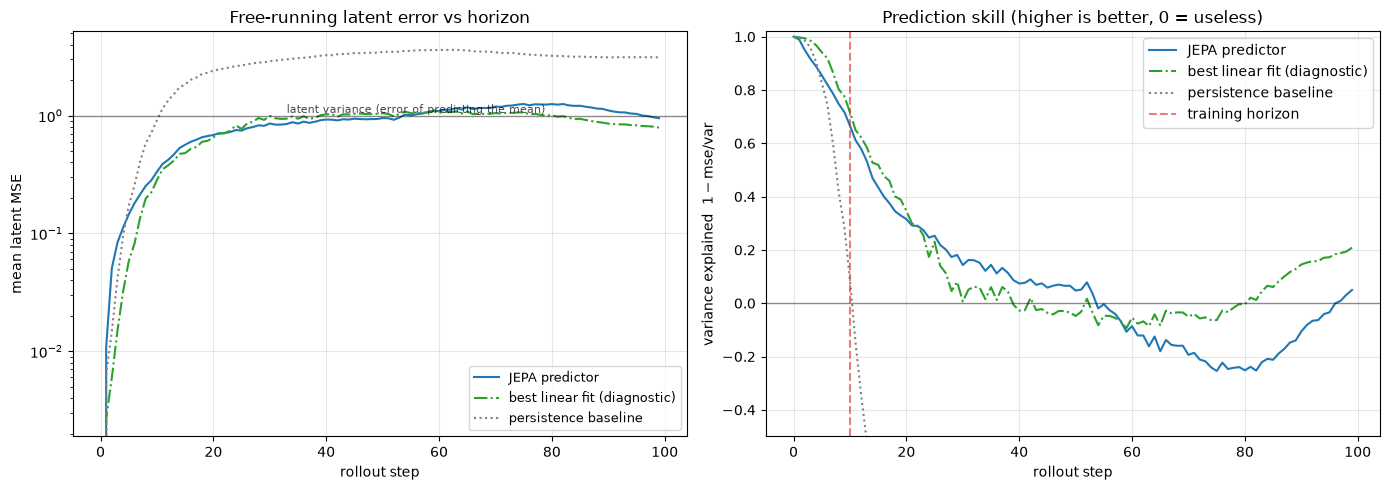

In [6]:
jp.fig_learning_curves(METRICS)
plt.show()

jp.fig_horizon_errors(herr, max_step=min(100, len(herr["steps"])))
plt.axvline(SCORE_HORIZON, color="C3", ls="--", alpha=0.6, label="training horizon")
plt.legend()
plt.show()


## 6. Is the latent structured around the quantities needed for control?

PCA is a qualitative check: smooth infected/susceptible gradients indicate that epidemic-relevant state occupies dominant latent directions. The ridge probe is stricter: MPC requires infection burden and the remaining susceptible pool to be recoverable from the latent, while `u_applied` measures whether current vaccination leaves a detectable signature.

High readout quality alone is not enough—the model must also carry those quantities accurately through free-running rollouts.


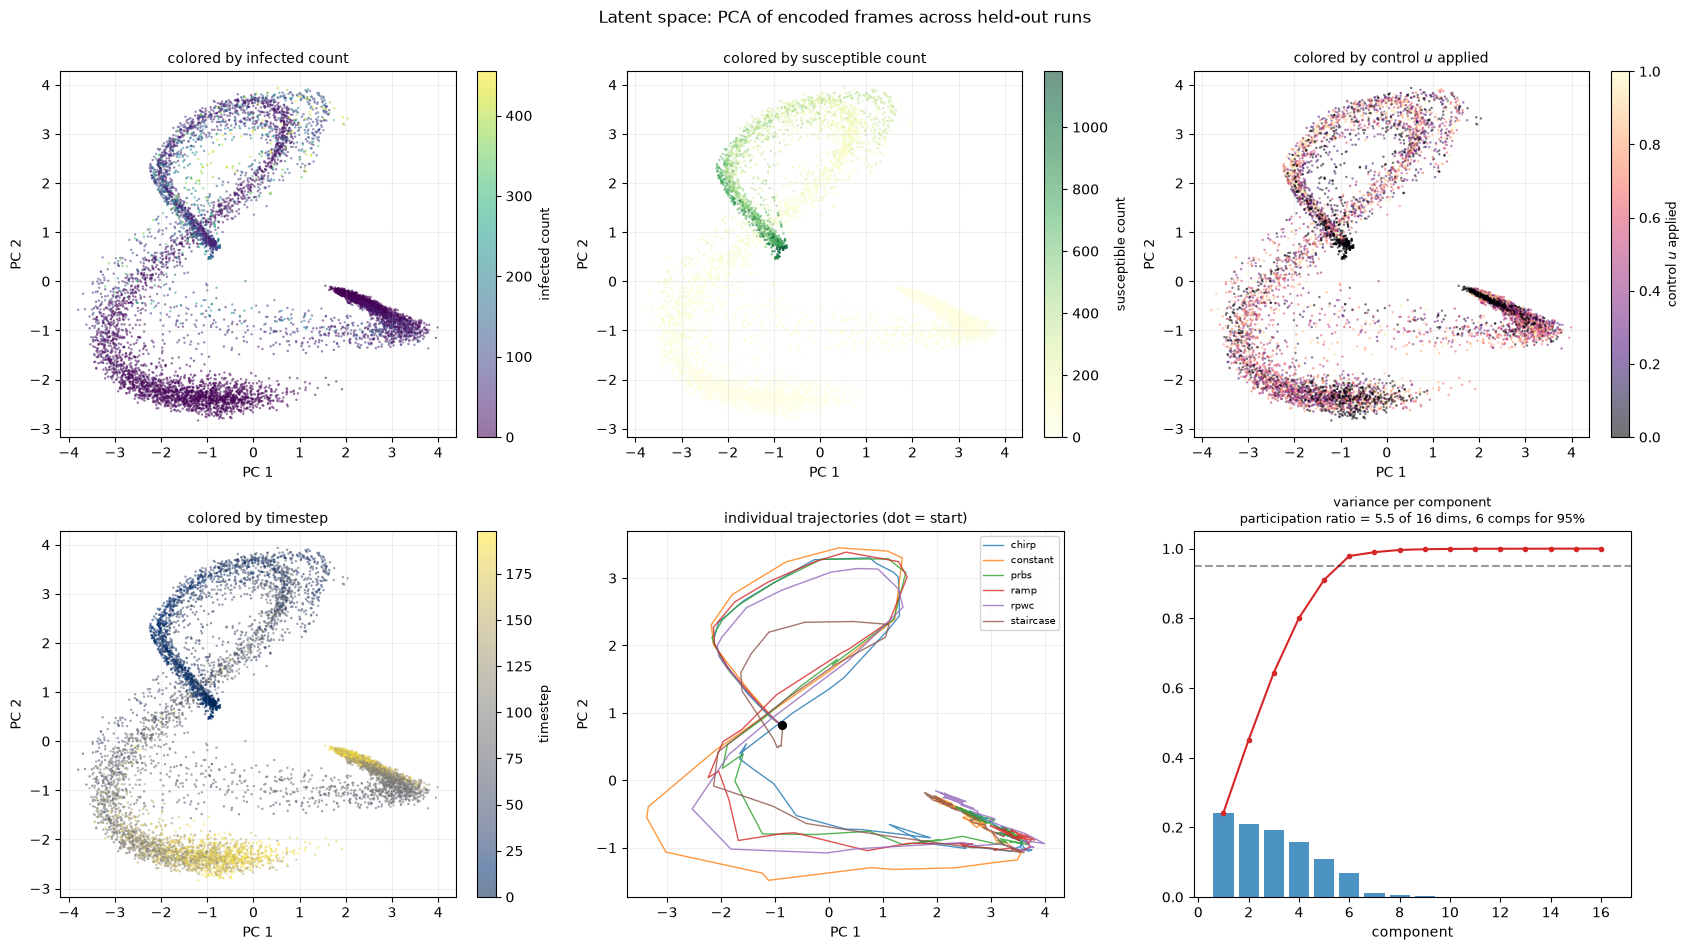

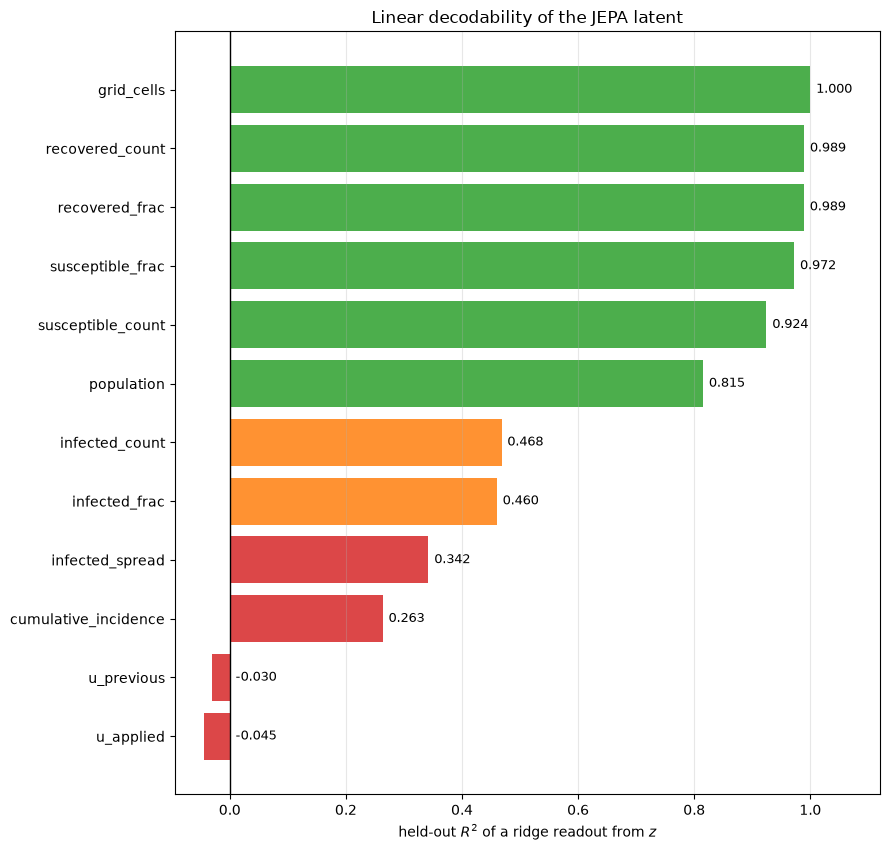

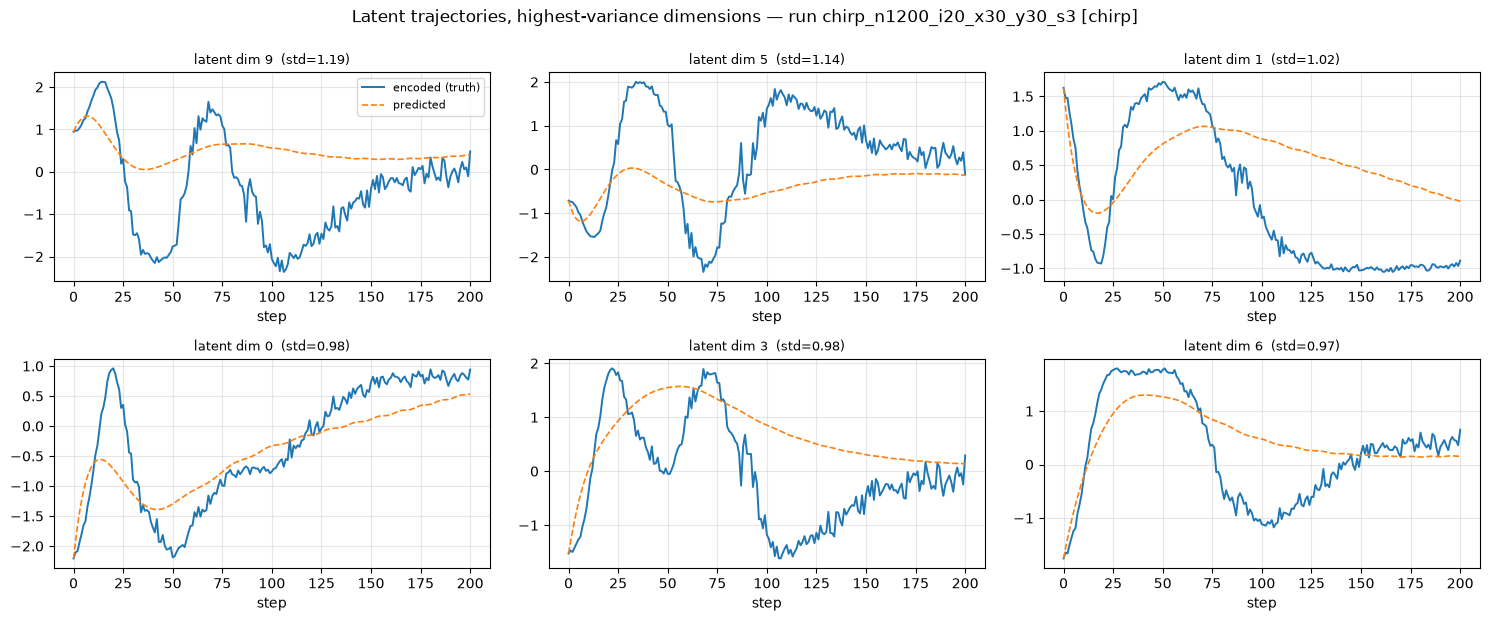

In [7]:
jp.fig_latent_pca(pca, stride=3, n_traj_lines=6)
plt.show()

jp.fig_latent_probe(probe)
plt.show()

jp.fig_latent_traces(model, val[0], n_dims=6)
plt.show()


## 7. Decoder-free readout and free-running macrostates

JEPA never reconstructs pixels. A post-hoc linear map converts predicted latents into the few observables needed by the controller. The scatter panels test static recoverability; the rollout panels test whether errors accumulate in the quantities that define the control objective.

The control shading is the vaccination signal supplied to the predictor—not an input inferred from the image.


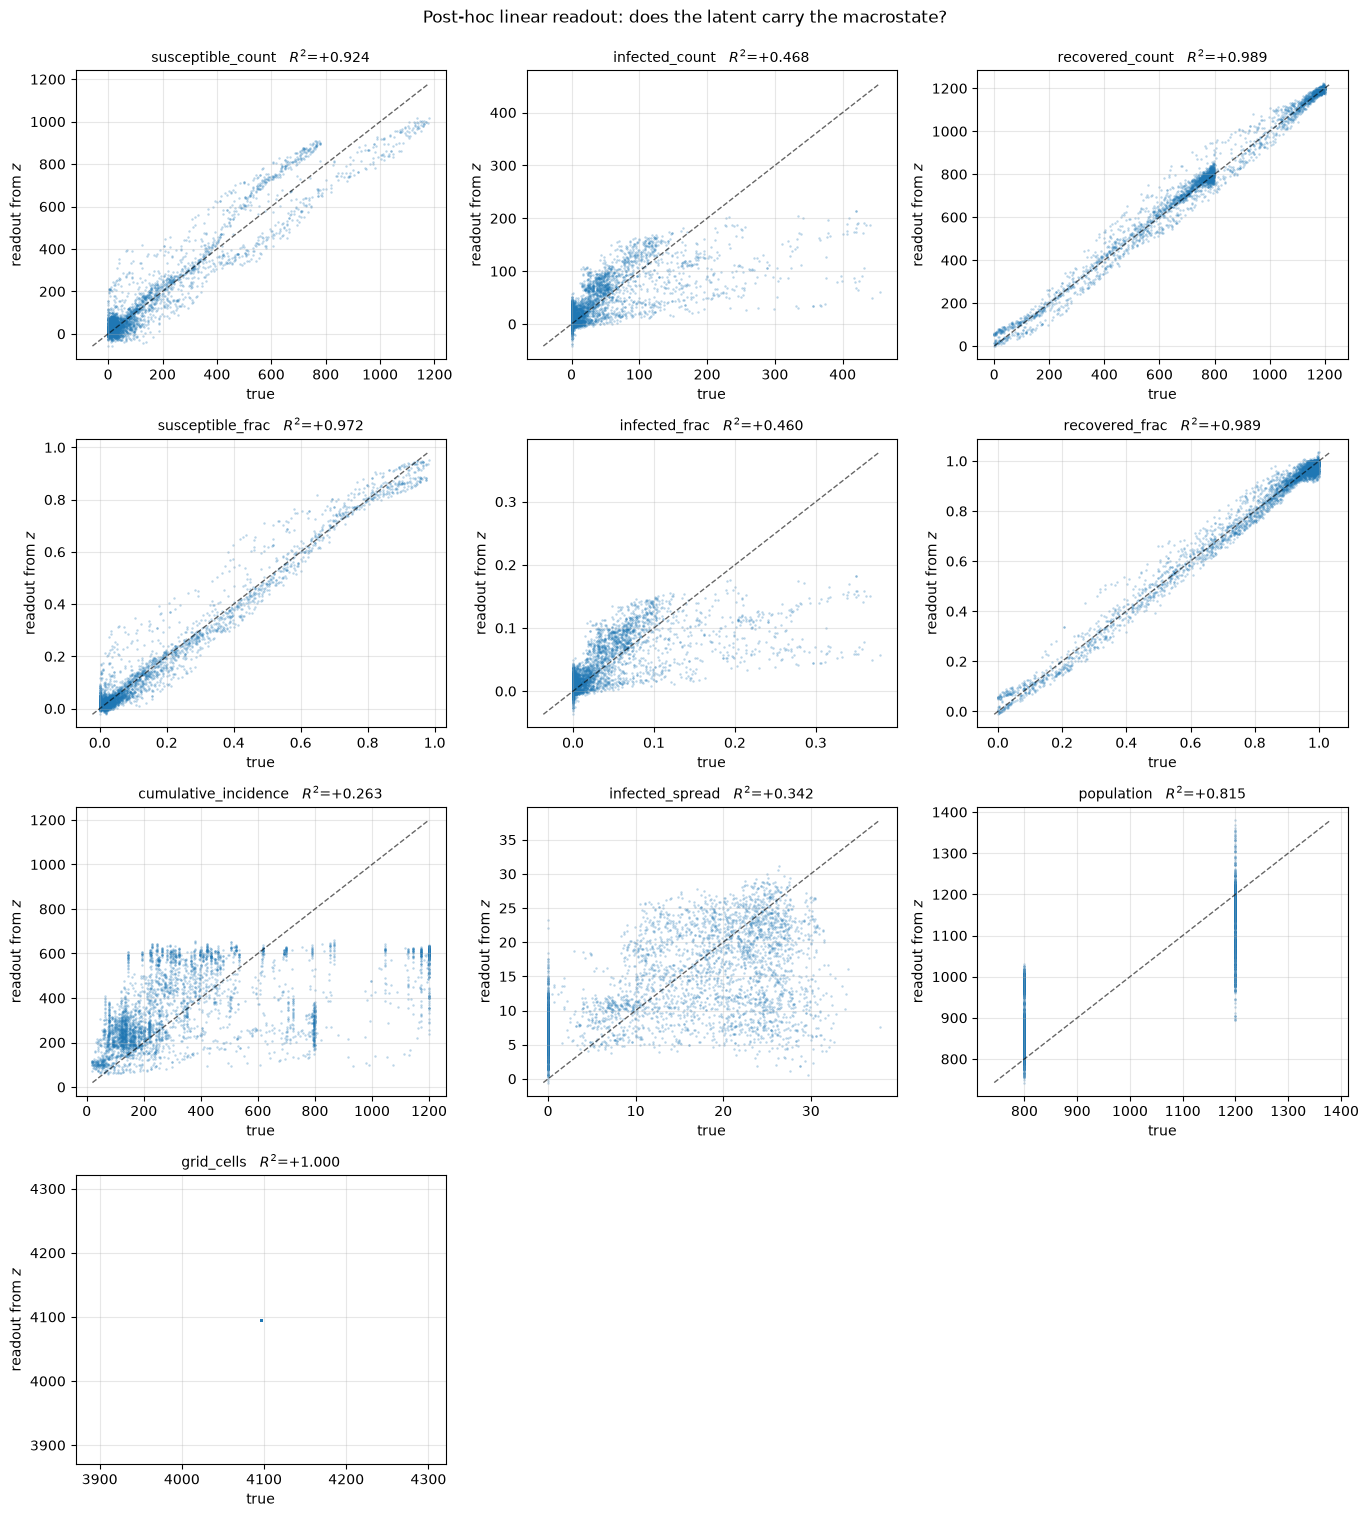

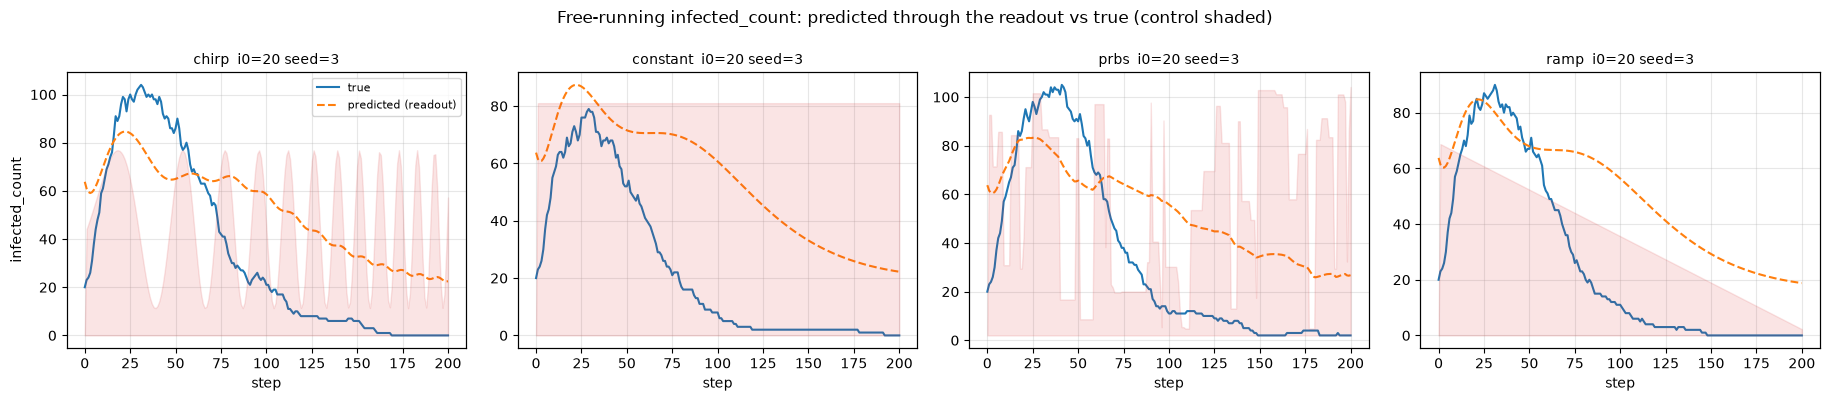

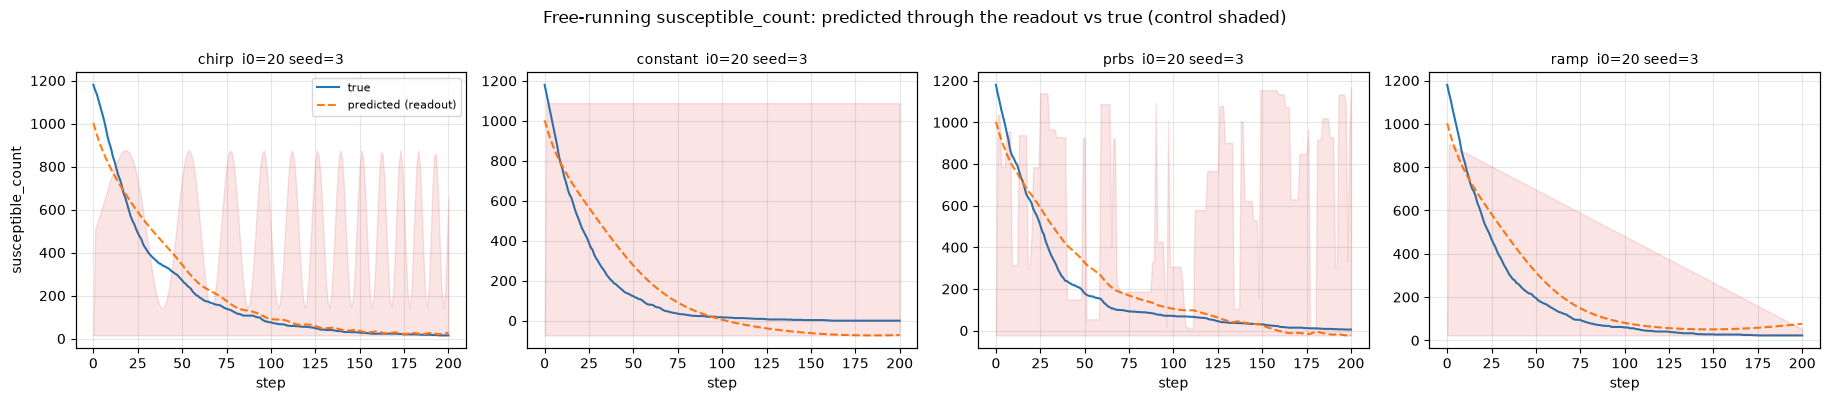

In [8]:
jp.fig_readout_quality(readout, enc, r2_val)
plt.show()

jp.fig_readout_rollout(model, val, readout, n=4, obs_name="infected_count")
plt.show()

jp.fig_readout_rollout(model, val, readout, n=4, obs_name="susceptible_count")
plt.show()


## 8. Does the learned model understand the vaccination trade-off?

For each constant dose, this runs matched true-ABM and latent-model trajectories from the same initial conditions. The black curves are the plant; dashed curves are what MPC would believe.

A usable model should predict **lower infected burden** as vaccination rises, while also predicting the decline in susceptibles. Getting only the infection curve right is insufficient for multi-objective planning.


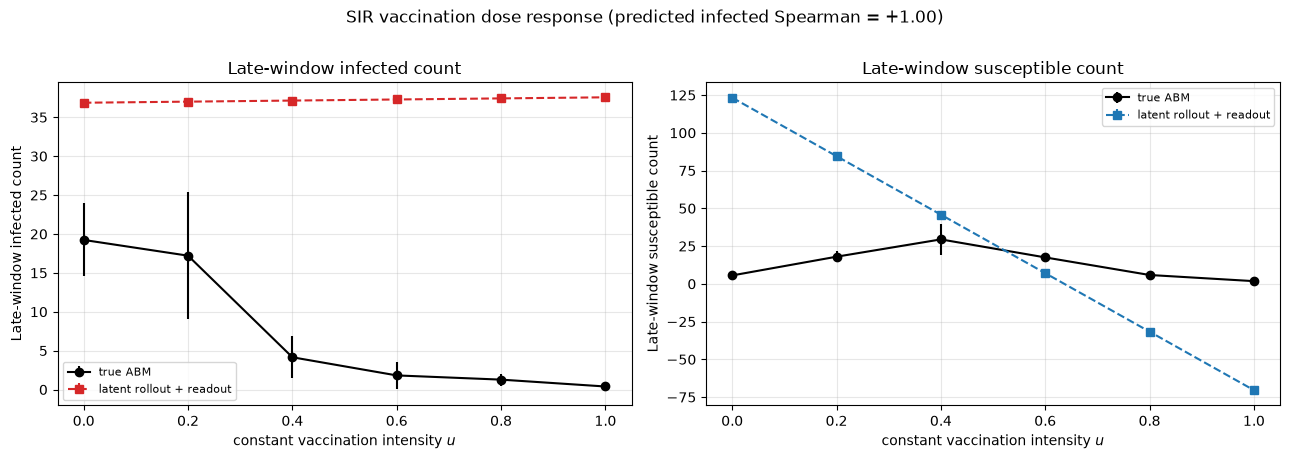

In [9]:
from dataclasses import fields
from koopman_control.data.agentic_sir import AgenticSIRConfig

abm_fields = {f.name for f in fields(AgenticSIRConfig)}
abm_kwargs = {k: v for k, v in manifest.get("config", {}).items() if k in abm_fields}
ABM_CFG = AgenticSIRConfig(**abm_kwargs)

dose = ev.sir_dose_response(
    model,
    readout,
    cfg=ABM_CFG,
    u_levels=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    seeds=(900, 901, 902),
    steps=160,
    n_agents=800,
    initial_infected=32,
)
jp.fig_sir_dose_response(dose)
plt.show()


### 8b. Dissecting the planner's internal world

CEM never sees the true ABM when planning — only free-running latent rollouts
through the readout. The solid curves below are exactly those beliefs: from one
shared initial latent, hold vaccination at a constant level and ask what the
model thinks will happen to infection and susceptibles.

Dashed curves are the matched true ABM. **Read the infected panel first:** if
solid curves rise with $u$ while dashed curves fall, MPC will prefer $u\approx 0$
even when the plant needs vaccination. The step/impulse panels isolate the
control contribution (deviation from $u=0$); for vaccination, predicted
infected should trend **down**, not up.


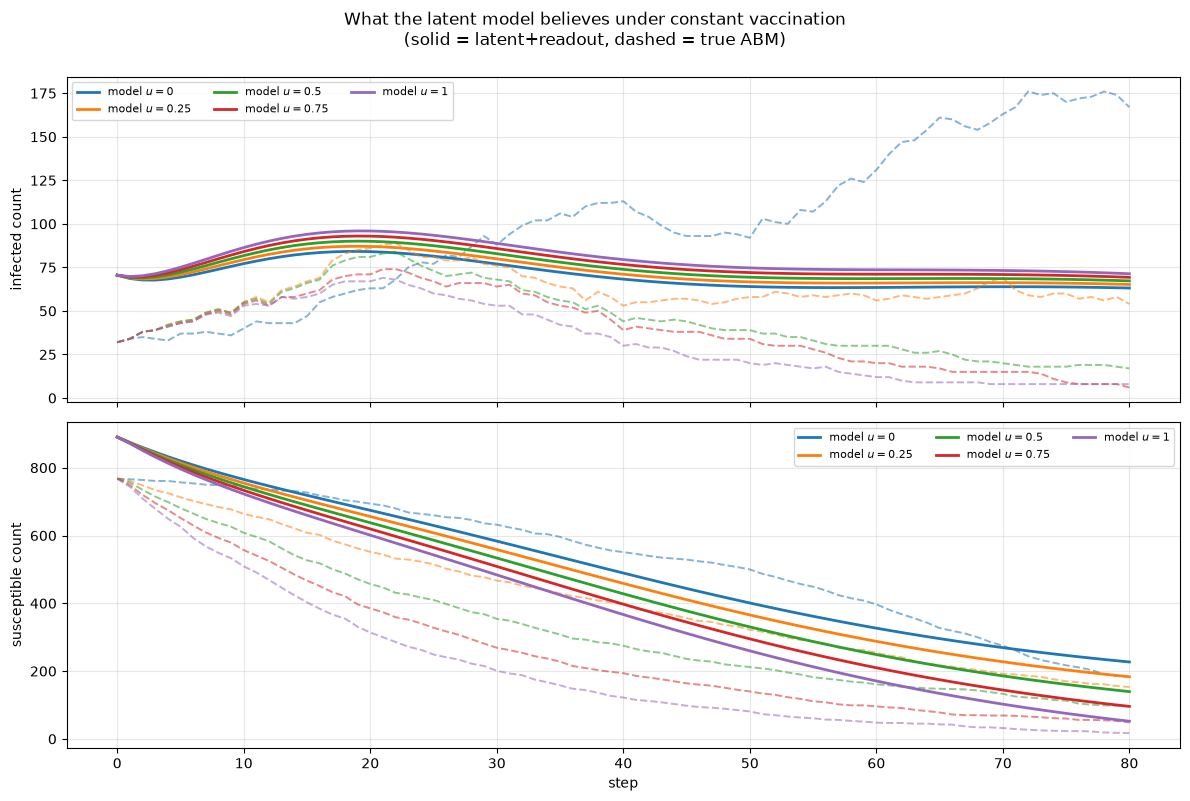

predicted infected @ h=10 / final:
  u=0: model 77.2 → 63.2   true 40.0 → 167.0
  u=0.25: model 79.5 → 65.2   true 55.0 → 54.0
  u=0.5: model 81.8 → 67.3   true 55.0 → 17.0
  u=0.75: model 84.1 → 69.3   true 54.0 → 6.0
  u=1: model 86.4 → 71.4   true 53.0 → 8.0

Step / impulse response of predicted infected (vs u=0):


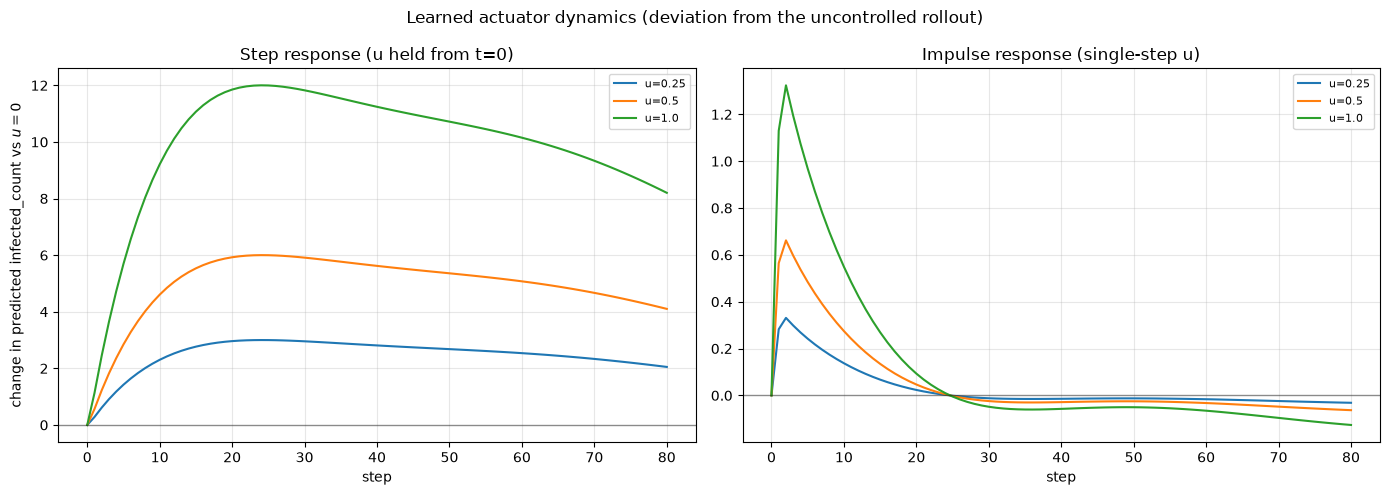

Step / impulse response of predicted susceptibles (vs u=0):


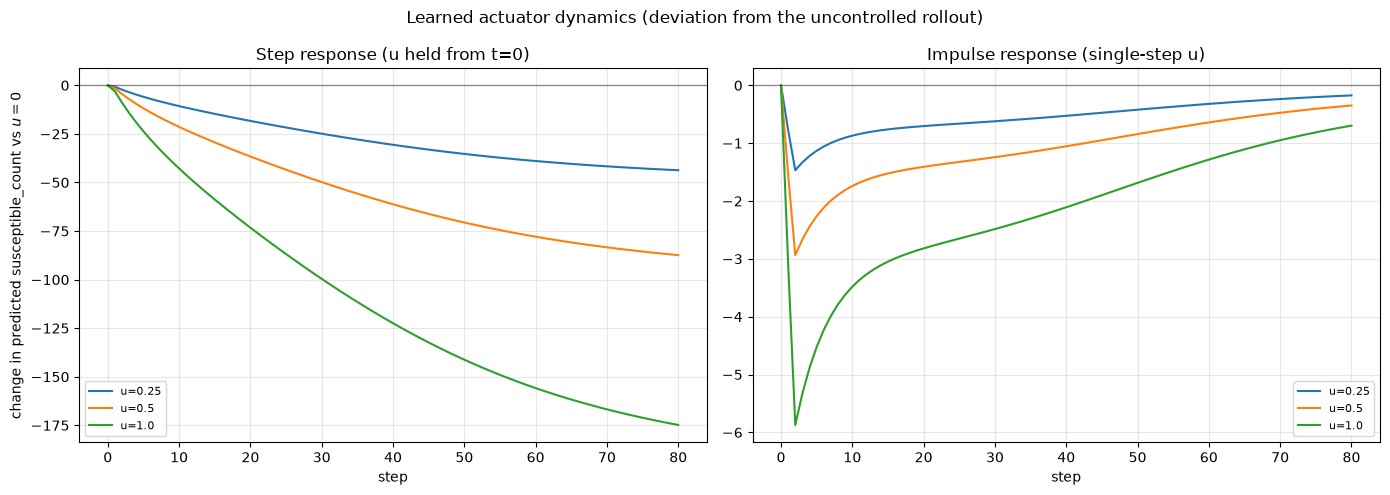

In [10]:
BELIEF_STEPS = 80
BELIEF_SEED = 950
BELIEF_N_AGENTS = 800
BELIEF_INITIAL_INFECTED = 32

beliefs = ev.sir_control_beliefs(
    model,
    readout,
    cfg=ABM_CFG,
    u_levels=(0.0, 0.25, 0.5, 0.75, 1.0),
    steps=BELIEF_STEPS,
    n_agents=BELIEF_N_AGENTS,
    initial_infected=BELIEF_INITIAL_INFECTED,
    seed=BELIEF_SEED,
    include_true=True,
)
jp.fig_sir_control_beliefs(beliefs)
plt.show()

# One-line sign check at the planning horizon and at the end of the window.
h = min(SCORE_HORIZON, BELIEF_STEPS)
print(f"predicted infected @ h={h} / final:")
for u in beliefs["u_levels"]:
    pred_i = beliefs["pred"][u]["infected"]
    true_i = beliefs["true"][u]["infected"]
    print(
        f"  u={u:g}: model {pred_i[h]:.1f} → {pred_i[-1]:.1f}   "
        f"true {true_i[h]:.1f} → {true_i[-1]:.1f}"
    )

print("\nStep / impulse response of predicted infected (vs u=0):")
jp.fig_step_response(
    model,
    beliefs["z0"],
    readout,
    steps=BELIEF_STEPS,
    obs_name="infected_count",
)
plt.show()

print("Step / impulse response of predicted susceptibles (vs u=0):")
jp.fig_step_response(
    model,
    beliefs["z0"],
    readout,
    steps=BELIEF_STEPS,
    obs_name="susceptible_count",
)
plt.show()


## 9. Multi-objective MPC against the true ABM

At every ABM step, CEM samples candidate vaccination sequences inside the learned latent model and minimizes

\[
J = w_I\sum_k\left(\frac{I_k-I^*}{s_I}\right)^2
  + w_S\sum_k\left(\frac{\max(S_{\mathrm{floor}}-S_k,0)}{s_S}\right)^2
  + \lambda_u\sum_k u_k^2
  + \lambda_{\Delta u}\sum_k (u_k-u_{k-1})^2.
\]

Only the first dose is applied; the true ABM advances one step and MPC replans. The weights below are scientific assumptions, not learned values. Compare MPC against constant-vaccination open-loop baselines on the same initial outbreak.


/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_53469/2470198475.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=3)


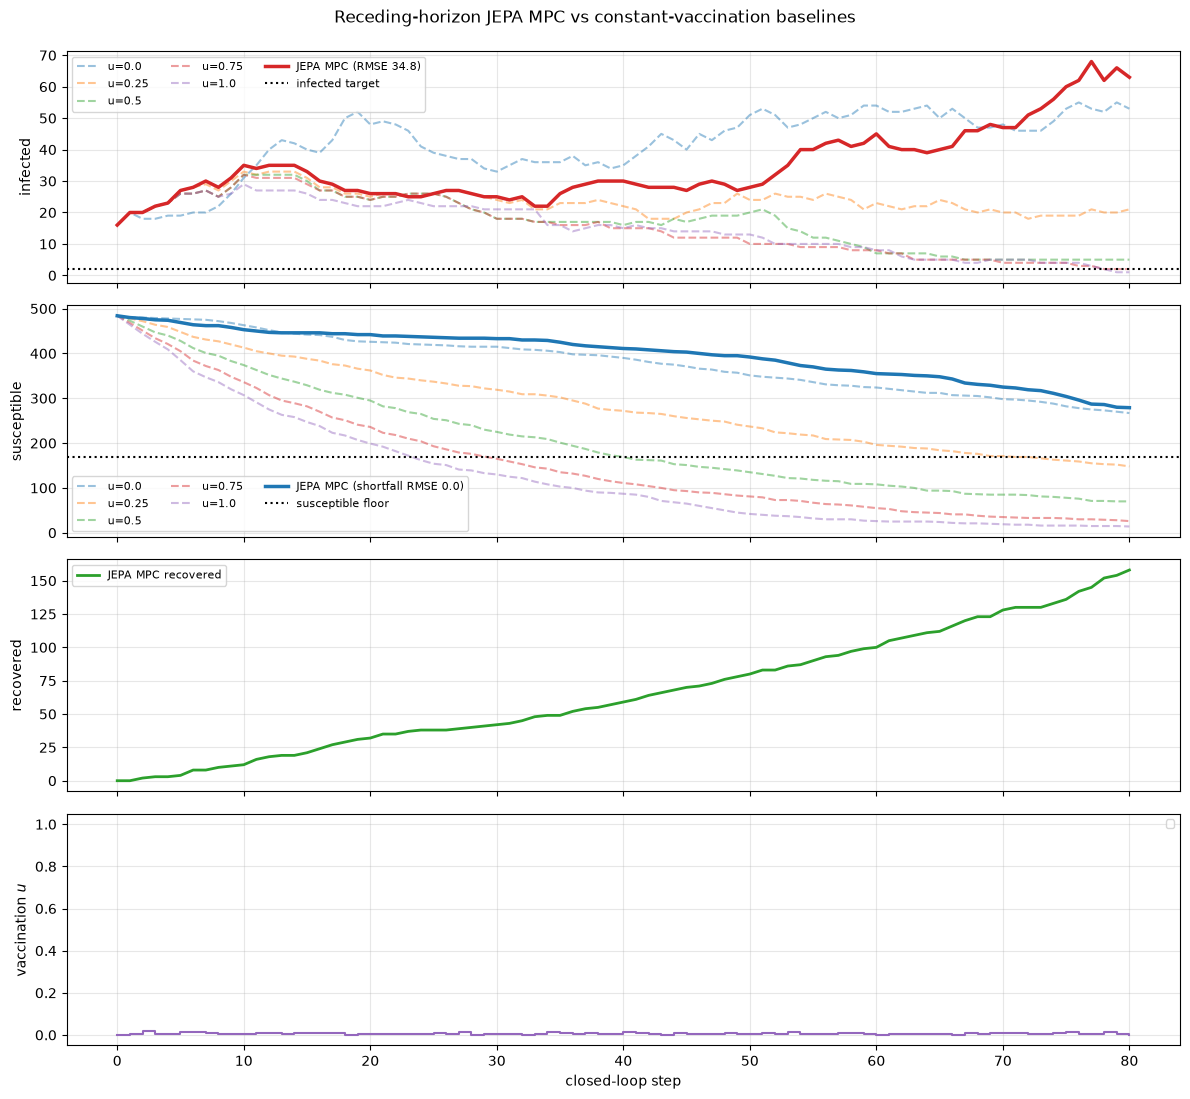

{'final_infected': 63.0, 'final_susceptible': 279.0, 'final_incidence': 216.0, 'mean_dose': 0.006536233238875866, 'cumulative_dose': 0.5228986740112305}


In [11]:
from jepa_control.control import SIRMPCConfig, closed_loop_sir, sir_baseline_rollouts

MPC_STEPS = 80
BASELINE_LEVELS = (0.0, 0.25, 0.5, 0.75, 1.0)
MPC_SEED = 950
MPC_N_AGENTS = 500
MPC_INITIAL_INFECTED = 16

baselines = sir_baseline_rollouts(
    steps=MPC_STEPS,
    levels=BASELINE_LEVELS,
    cfg=ABM_CFG,
    n_agents=MPC_N_AGENTS,
    initial_infected=MPC_INITIAL_INFECTED,
    seed=MPC_SEED,
)
initial_infected = float(next(iter(baselines.values()))["infected"][0])
initial_susceptible = float(next(iter(baselines.values()))["susceptible"][0])
INFECTED_TARGET = max(2.0, 0.05 * initial_infected)

mpc_cfg = SIRMPCConfig(
    plan_horizon=SCORE_HORIZON,
    n_samples=128,
    n_iters=3,
    elite_frac=0.1,
    infected_weight=2.0,
    susceptible_weight=0.2,
    control_cost=0.02,
    slew_cost=0.1,
    infected_scale=max(initial_infected, 1.0),
    susceptible_scale=max(initial_susceptible, 1.0),
)
mpc_result = closed_loop_sir(
    model,
    readout,
    infected_target=INFECTED_TARGET,
    steps=MPC_STEPS,
    mpc=mpc_cfg,
    cfg=ABM_CFG,
    n_agents=MPC_N_AGENTS,
    initial_infected=MPC_INITIAL_INFECTED,
    seed=MPC_SEED,
)

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
for label, result in baselines.items():
    axes[0].plot(result["infected"], ls="--", alpha=0.45, label=label)
    axes[1].plot(result["susceptible"], ls="--", alpha=0.45, label=label)
axes[0].plot(
    mpc_result["infected"],
    color="C3",
    lw=2.5,
    label=f"JEPA MPC (RMSE {mpc_result['infected_rmse']:.1f})",
)
axes[0].axhline(INFECTED_TARGET, color="k", ls=":", label="infected target")
axes[1].plot(
    mpc_result["susceptible"],
    color="C0",
    lw=2.5,
    label=f"JEPA MPC (shortfall RMSE {mpc_result['susceptible_shortfall_rmse']:.1f})",
)
axes[1].axhline(mpc_result["susceptible_floor"], color="k", ls=":", label="susceptible floor")
axes[2].plot(mpc_result["recovered"], color="C2", lw=2.0, label="JEPA MPC recovered")
axes[3].step(np.arange(len(mpc_result["control"])), mpc_result["control"], where="post", color="C4")
axes[0].set_ylabel("infected"); axes[1].set_ylabel("susceptible")
axes[2].set_ylabel("recovered"); axes[3].set_ylabel("vaccination $u$")
axes[3].set_xlabel("closed-loop step"); axes[3].set_ylim(-0.05, 1.05)
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=3)
fig.suptitle("Receding-horizon JEPA MPC vs constant-vaccination baselines", y=0.995)
fig.tight_layout(); plt.show()

print({
    k: mpc_result[k]
    for k in (
        "final_infected",
        "final_susceptible",
        "final_incidence",
        "mean_dose",
        "cumulative_dose",
    )
})


## 10. Final held-out test split

Use validation for iteration and inspect this section only after choices are fixed. Report infected and susceptible performance separately: a model can predict infection dynamics while missing susceptibility depletion, which would make the resulting controller over-vaccinate even if its infection objective looks good.


test prediction skill @ h=10: +0.659
test infected:   readout R²=+0.459, rollout corr=+0.507, RMSE=60.95
test susceptible: readout R²=+0.926, rollout corr=+0.932, RMSE=108.84
test excitation families: ['chirp', 'constant', 'prbs', 'ramp', 'rpwc', 'staircase', 'zero']


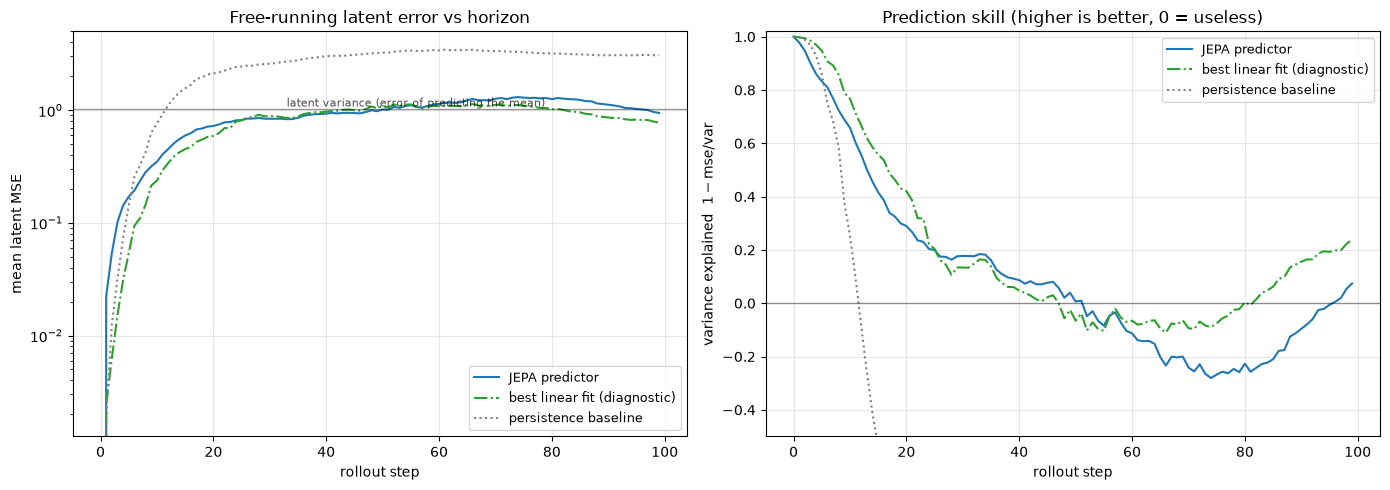

In [12]:
enc_test = ev.encode_all(model, test)
r2_test = ev.readout_r2(readout, enc_test)
herr_test = ev.horizon_errors(model, enc_test, fitted)
infected_test = ev.readout_rollout_skill(model, enc_test, readout, obs_name="infected_count")
susceptible_test = ev.readout_rollout_skill(model, enc_test, readout, obs_name="susceptible_count")
h_test = min(SCORE_HORIZON, len(herr_test["steps"]) - 1)

print(f"test prediction skill @ h={h_test}: {herr_test['skill_full'][h_test]:+.3f}")
print(f"test infected:   readout R²={r2_test['infected_count']:+.3f}, rollout corr={infected_test['corr']:+.3f}, RMSE={infected_test['rmse']:.2f}")
print(f"test susceptible: readout R²={r2_test['susceptible_count']:+.3f}, rollout corr={susceptible_test['corr']:+.3f}, RMSE={susceptible_test['rmse']:.2f}")
print("test excitation families:", sorted({tr["excitation"] for tr in test}))

jp.fig_horizon_errors(herr_test, max_step=min(100, len(herr_test["steps"])))
plt.show()


## 12. Baseline: fit an SIR ODE and control with it

Skip images: fit a discrete three-state ODE on `(susceptible_count, infected_count, recovered_count)` with delayed vaccination delivery, and run the **same multi-objective CEM MPC** with oracle population counts each step.

$$
\begin{aligned}
S' &= S - \beta\,S I/N - \delta u - \lambda u_{\mathrm{prev}} \\
I' &= I + \beta\,S I/N - \gamma I \\
R' &= R + \gamma I + \delta u + \lambda u_{\mathrm{prev}}
\end{aligned}
$$

Parameters are least-squares fits on one-step deltas from the train probe set. Closed loop still acts on the true agentic ABM, but the ODE planner gets **oracle** compartment counts each step (not image → latent → readout). If JEPA cannot match this under the same target / weights / horizon / seed as section 9, the latent controller is not yet earning its complexity.


fitted SIR ODE
  transmission beta=0.117931  recovery gamma=0.033494
  vaccination  now=0.0400  lag=0.0027
  one-step R²  infected=+0.486  susceptible=+0.674  recovered=+0.801

val free-rollout @ h=10:
  infected   ODE skill +0.164  (persistence -2.348)
  susceptible ODE skill +0.844  (persistence -2.587)

ODE MPC   infected RMSE 15.8, susceptible shortfall 90.0, mean dose 0.641
JEPA MPC  infected RMSE 34.8, susceptible shortfall 0.0, mean dose 0.007
JEPA − ODE infected RMSE: +19.0  (ODE better)
JEPA − ODE susceptible shortfall RMSE: -90.0  (JEPA better)


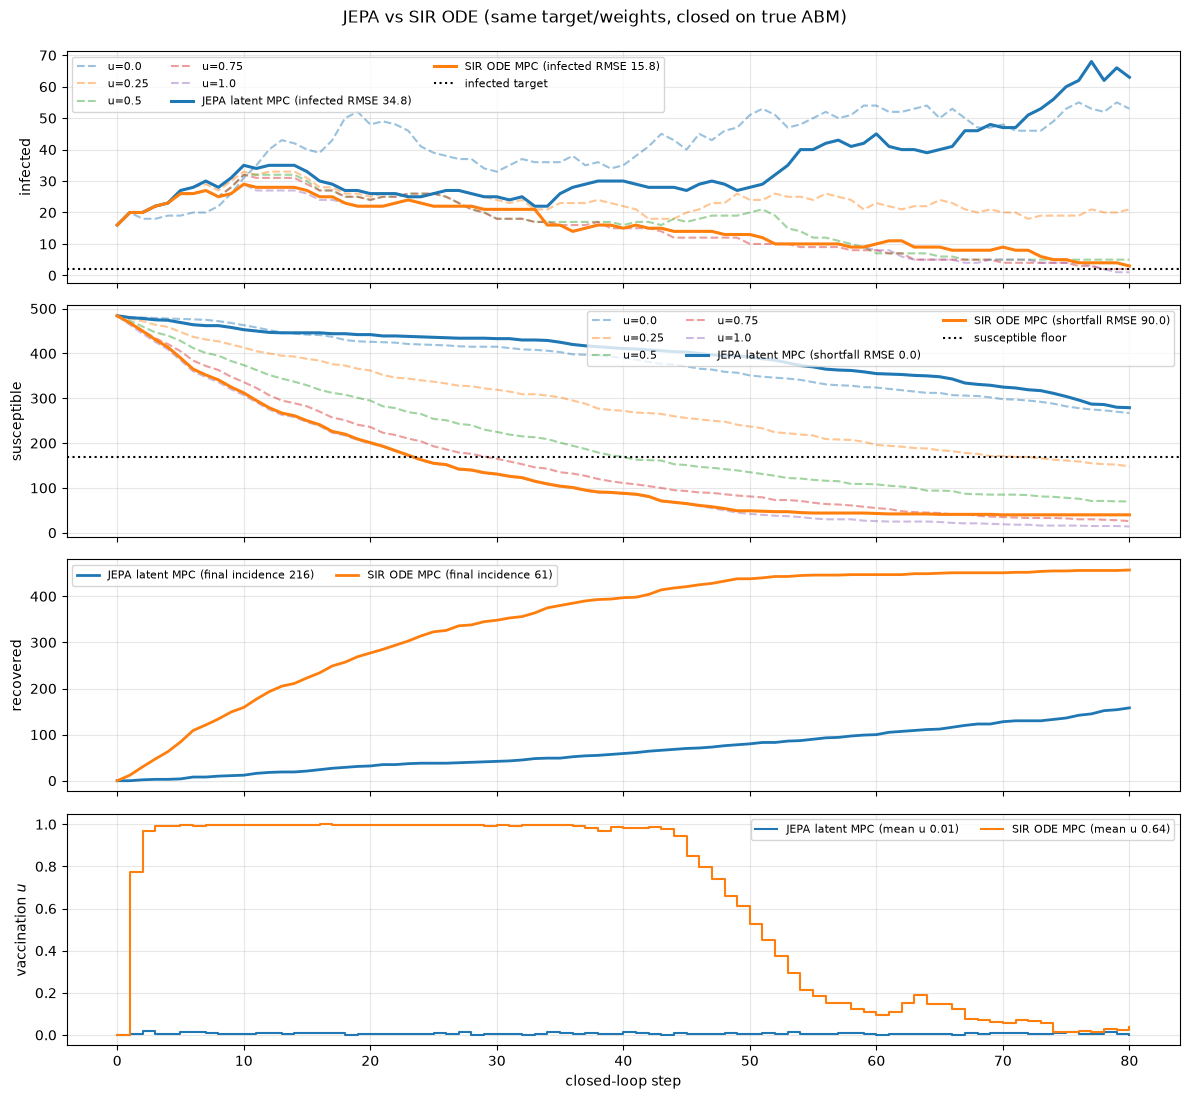

In [13]:
from jepa_control.ode_baseline import (
    closed_loop_sir_ode,
    fit_sir_ode,
    sir_ode_prediction_skill,
)
from jepa_control.plots import fig_sir_controller_compare

ode_train = probe_train
ode = fit_sir_ode(ode_train)
print("fitted SIR ODE")
print(f"  transmission beta={ode.beta:.6f}  recovery gamma={ode.gamma:.6f}")
print(f"  vaccination  now={ode.vacc_now:.4f}  lag={ode.vacc_lag:.4f}")
print(
    f"  one-step R²  infected={ode.infected_one_step_r2:+.3f}  "
    f"susceptible={ode.susceptible_one_step_r2:+.3f}  "
    f"recovered={ode.recovered_one_step_r2:+.3f}"
)

infected_ode_skill = sir_ode_prediction_skill(
    val, ode, horizon=SCORE_HORIZON, obs_name="infected_count"
)
susceptible_ode_skill = sir_ode_prediction_skill(
    val, ode, horizon=SCORE_HORIZON, obs_name="susceptible_count"
)
print(f"\nval free-rollout @ h={SCORE_HORIZON}:")
print(
    f"  infected   ODE skill {infected_ode_skill['skill']:+.3f}  "
    f"(persistence {infected_ode_skill['skill_persistence']:+.3f})"
)
print(
    f"  susceptible ODE skill {susceptible_ode_skill['skill']:+.3f}  "
    f"(persistence {susceptible_ode_skill['skill_persistence']:+.3f})"
)

ode_loop = closed_loop_sir_ode(
    ode,
    infected_target=INFECTED_TARGET,
    steps=MPC_STEPS,
    mpc=mpc_cfg,
    cfg=ABM_CFG,
    n_agents=MPC_N_AGENTS,
    initial_infected=MPC_INITIAL_INFECTED,
    seed=MPC_SEED,
)
print(
    f"\nODE MPC   infected RMSE {ode_loop['infected_rmse']:.1f}, "
    f"susceptible shortfall {ode_loop['susceptible_shortfall_rmse']:.1f}, "
    f"mean dose {ode_loop['mean_dose']:.3f}"
)
print(
    f"JEPA MPC  infected RMSE {mpc_result['infected_rmse']:.1f}, "
    f"susceptible shortfall {mpc_result['susceptible_shortfall_rmse']:.1f}, "
    f"mean dose {mpc_result['mean_dose']:.3f}"
)
d_infected = mpc_result["infected_rmse"] - ode_loop["infected_rmse"]
d_susceptible = mpc_result["susceptible_shortfall_rmse"] - ode_loop["susceptible_shortfall_rmse"]
print(
    f"JEPA − ODE infected RMSE: {d_infected:+.1f}  "
    f"({'JEPA better' if d_infected < 0 else 'ODE better' if d_infected > 0 else 'tie'})"
)
print(
    f"JEPA − ODE susceptible shortfall RMSE: {d_susceptible:+.1f}  "
    f"({'JEPA better' if d_susceptible < 0 else 'ODE better' if d_susceptible > 0 else 'tie'})"
)

fig_sir_controller_compare(
    {"JEPA latent MPC": mpc_result, "SIR ODE MPC": ode_loop},
    baselines,
    title="JEPA vs SIR ODE (same target/weights, closed on true ABM)",
)
plt.show()


## 11. Reading the result

A credible result should satisfy all of these:

- **Dataset:** vaccination produces graded—not binary—infection and susceptible responses across varied spatial initial conditions.
- **No collapse:** multiple latent dimensions remain active; low prediction loss alone does not establish this.
- **Dynamics:** JEPA beats persistence near the training horizon on validation and test.
- **State legibility:** held-out readout $R^2$ is high for both `infected_count` and `susceptible_count`.
- **Control understanding:** dose-response Spearman correlation is positive for infection; susceptibles fall with dose.
- **Closed loop:** MPC drives infection toward the target without saturating vaccination when infection is already low.
- **ODE baseline:** under the same MPC weights and seed, compare against an oracle compartment ODE planner fit on train macros (section 12).
